<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 5. Итеративные и оптимизационные атаки: PGD, C&W, JSMA

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 4**

**Формат:** индивидуально или в парах

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить методы построения многошаговых и оптимизационных evasion-атак и научиться сравнивать их по силе, вычислительной стоимости и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- реализовывать PGD-атаку с проекцией на $L_\infty$-шар и случайным стартом;
- объяснять формулировку седловой точки (min-max) и её связь с adversarial training;
- реализовывать целевую C&W L2-атаку с заменой переменных через tanh и параметром confidence κ;
- реализовывать JSMA на основе якобиана выхода модели и точечного насыщения признаков;
- сравнивать атаки по Attack Success Rate, норме возмущения и вычислительным затратам.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Атаки на MNIST могут занимать заметное время на CPU (особенно JSMA) — рассчитывайте время выполнения заранее.


## 0. Подготовка окружения

In [1]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

RANDOM_STATE = 42
# TODO: зафиксируйте seed для torch и numpy
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Часть I. Данные и базовая модель

**Задание:** загрузите MNIST и обучите небольшую CNN (2 свёрточных слоя + полносвязный классификатор) — эта модель станет целью для всех атак в работе.

In [2]:
# TODO: загрузите MNIST через torchvision.datasets
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2)

In [3]:
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс CNN (2 свёрточных слоя, max pooling, полносвязный классификатор)
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [4]:
# TODO: обучите модель на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = SmallCNN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def train_model(model, loader, optimizer, criterion, epochs=3):
    model.train()
    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
    return model
# TODO: цикл обучения
model = train_model(model, train_loader,optimizer,criterion)


In [5]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_accuracy = correct / total
print(f"Clean accuracy: {clean_accuracy}")


Clean accuracy: 0.9879


## Часть II. Projected Gradient Descent (PGD)

### 2.1. Реализация PGD

**Задание:** реализуйте функцию PGD-атаки по формуле

$$
x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t + \alpha \cdot \operatorname{sign}\left( \nabla_x L(\theta, x^t, y) \right) \right)
$$

Функция должна:
1. Инициализировать возмущение случайно внутри $\epsilon$-шара (random start).
2. На каждой итерации пересчитывать градиент и делать шаг по знаку градиента.
3. Проецировать (clip) возмущение на $\epsilon$-шар и итоговый пиксель — на диапазон $[0,1]$.

In [6]:
# TODO: реализуйте функцию PGD-атаки
def pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    # TODO:
    # 1. Инициализация delta (случайная или нулевая)
    # 2. Цикл на num_iter итераций:
    #    - forward pass через model(x + delta)
    #    - вычисление loss и backward
    #    - обновление delta по знаку градиента
    #    - проекция на epsilon-шар (torch.clamp)
    #    - проекция на допустимый диапазон [0, 1]
    #    - обнуление градиента

    # 1. Инициализация возмущения delta
    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(x)

    delta.requires_grad = True

    # 2. Цикл на num_iter итераций
    for _ in range(num_iter):
        outputs = model(x + delta)
        loss = criterion(outputs, y)
        model.zero_grad()
        if delta.grad is not None:
            delta.grad.zero_()

        loss.backward()

        # Обновление delta по знаку градиента
        delta.data = delta.data + alpha * torch.sign(delta.grad)

        # Проекция на epsilon-шар
        delta.data = torch.clamp(delta.data, -epsilon, epsilon)

        # Проекция на допустимый диапазон [0, 1]
        x_adv = torch.clamp(x + delta.data, 0, 1)
        delta.data = x_adv - x

    return x + delta


### 2.2. Визуализация: FGSM vs PGD

**Задание:** реализуйте FGSM (для сравнения), затем на одном тестовом примере постройте adversarial-версии обоими методами при одинаковом \$epsilon$ и визуализируйте результат (3 подграфика: оригинал, FGSM, PGD) с указанием предсказаний модели.

In [7]:
# TODO: реализуйте FGSM (напоминание из предыдущей лабораторной)
def fgsm_attack(model, x, y, epsilon, criterion):
    # Отслеживание градиента для x
    x_adv = x.clone().detach().requires_grad_(True)

    output = model(x_adv)
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()

    # Возмущение epsilon * sign(grad)
    grad_sign = x_adv.grad.sign()
    perturbation = epsilon * grad_sign

    x_adv = x + perturbation
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

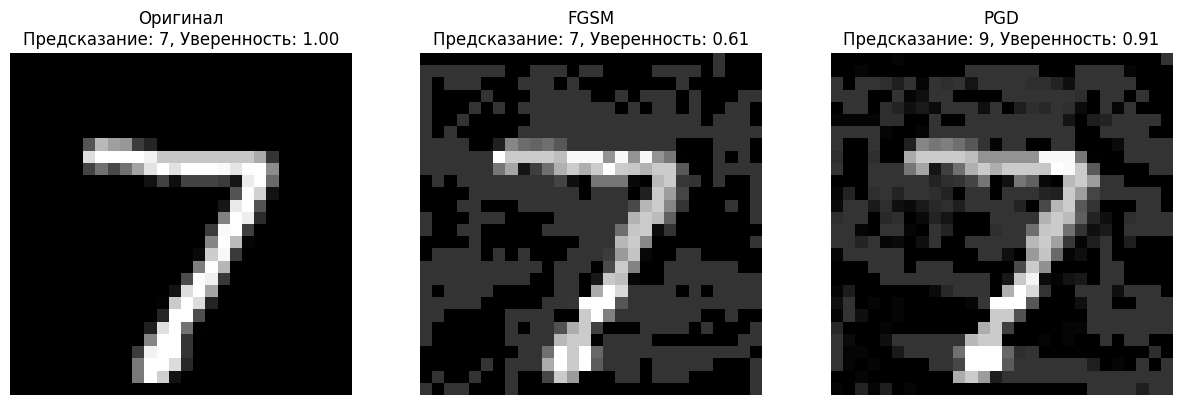

In [8]:
# TODO: выберите тестовый пример
# TODO: примените fgsm_attack и pgd_attack с epsilon=0.2 (для PGD: alpha=0.02, num_iter=40)
# TODO: постройте визуализацию из 3 подграфиков с предсказаниями модели
dataiter = iter(test_loader)
images, labels = next(dataiter)

x_orig = images[0:1].to(device)
y_true = labels[0:1].to(device)

epsilon = 0.2
num_iter=40
alpha=0.02
x_fgsm = fgsm_attack(model, x_orig, y_true, epsilon, criterion)
x_pgd = pgd_attack(model,x_orig,y_true,epsilon,alpha,num_iter,criterion)

model.eval()
with torch.no_grad():
    # Предсказание на оригинале
    out_orig = model(x_orig)
    prob_orig = F.softmax(out_orig, dim=1)
    pred_orig = prob_orig.argmax(dim=1).item()
    conf_orig = prob_orig[0, pred_orig].item()

    # Предсказание на adversarial примере
    out_fgsm = model(x_fgsm)
    prob_fgsm = F.softmax(out_fgsm, dim=1)
    pred_fgsm = prob_fgsm.argmax(dim=1).item()
    conf_fgsm = prob_fgsm[0, pred_fgsm].item()

    out_pgd = model(x_pgd)
    prob_pgd = F.softmax(out_pgd, dim=1)
    pred_pgd = prob_pgd.argmax(dim=1).item()
    conf_pgd = prob_pgd[0, pred_pgd].item()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(x_orig.cpu().numpy()[0, 0], cmap='gray')
axes[0].set_title(f"Оригинал\nПредсказание: {pred_orig}, Уверенность: {conf_orig:.2f}")
axes[0].axis('off')

axes[1].imshow(x_fgsm.cpu().numpy()[0, 0], cmap='gray')
axes[1].set_title(f"FGSM\nПредсказание: {pred_fgsm}, Уверенность: {conf_fgsm:.2f}")
axes[1].axis('off')

axes[2].imshow(x_pgd.detach().cpu().numpy()[0, 0], cmap='gray')
axes[2].set_title(f"PGD\nПредсказание: {pred_pgd}, Уверенность: {conf_pgd:.2f}")
axes[2].axis('off')

**Вопрос для отчёта:** отличаются ли визуально возмущения FGSM и PGD? Какой метод успешнее меняет предсказание модели при одном и том же ε?

_Ваш ответ:_   
Возмущения FGSM и PGD визуально отличаются - при PGD возмущение более "плавное"  
На данном примере FGSM атака не удалась, модель предсказала верный класс, но с низкой уверенностью 0.61  
PGD атака прошла успешно, модель предсказала класс 3 вместо 7, при чем с большой уверенностью 0.98

### 2.3. Attack Success Rate: FGSM vs PGD

**Задание:** постройте график зависимости Attack Success Rate от бюджета $\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}$ для FGSM и PGD (20 итераций) на одном графике.

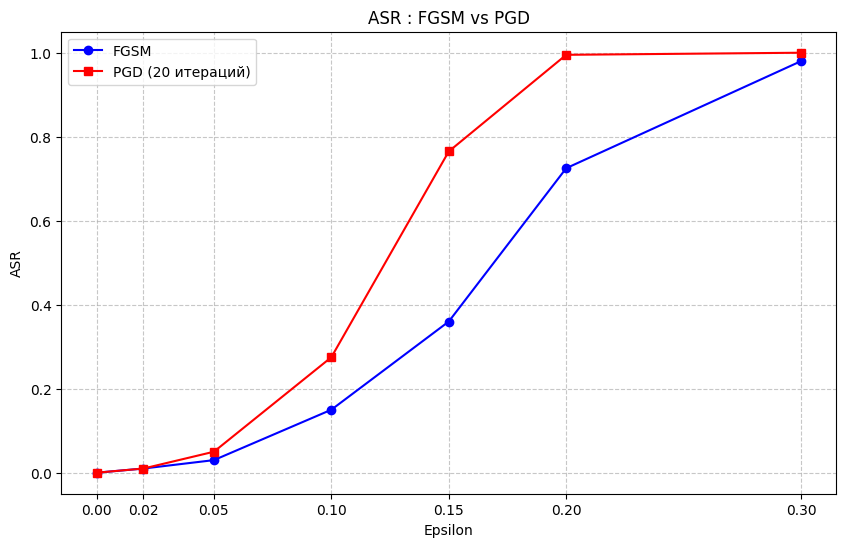

In [9]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки
from torch.utils.data import DataLoader, Subset
def evaluate_asr(model, loader, attack_fn, criterion, n_batches=10, **attack_kwargs):
    model.eval()
    total_examples = 0
    changed_predictions = 0

    device = next(model.parameters()).device

    epsilon = attack_kwargs.get('epsilon', 0.0)

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break

        images, labels = images.to(device), labels.to(device)
        total_examples += images.size(0)

        # Предсказания на оригинальных изображениях
        with torch.no_grad():
            outputs_orig = model(images)
            pred_orig = outputs_orig.argmax(dim=1)

        if epsilon > 0:
            # Генерируем состязательные примеры с помощью переданной атаки
            x_adv = attack_fn(model, images, labels, criterion=criterion, **attack_kwargs)

            with torch.no_grad():
                outputs_adv = model(x_adv)
                pred_adv = outputs_adv.argmax(dim=1)
            changed_predictions += (pred_adv != pred_orig).sum().item()

    return changed_predictions / total_examples

epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
# TODO: рассчитайте ASR для FGSM и PGD при каждом epsilon
# TODO: постройте сравнительный график
asr_fgsm = []
asr_pgd = []
indices = list(range(200))
subset_dataset = Subset(test_loader.dataset, indices)
fast_loader = DataLoader(subset_dataset, batch_size=200, shuffle=False)
for eps in epsilons:
    asr_f = evaluate_asr(
        model, fast_loader, fgsm_attack, criterion,
        n_batches=10, epsilon=eps
    )
    asr_fgsm.append(asr_f)

    asr_p = evaluate_asr(
        model, fast_loader, pgd_attack, criterion,
        n_batches=10, epsilon=eps, alpha=0.02, num_iter=20, randomize=True
    )
    asr_pgd.append(asr_p)


plt.figure(figsize=(10, 6))

plt.plot(epsilons, asr_fgsm, marker='o', linestyle='-', color='blue', label='FGSM')
plt.plot(epsilons, asr_pgd, marker='s', linestyle='-', color='red', label='PGD (20 итераций)')

plt.title('ASR : FGSM vs PGD')
plt.xlabel('Epsilon')
plt.ylabel('ASR')
plt.xticks(epsilons)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


### 2.4. Влияние числа итераций PGD

**Задание:** зафиксируйте $\epsilon = 0.15$ и постройте график зависимости ASR от числа итераций PGD $\in \{1, 2, 5, 10, 20, 40, 80\}$. Определите, при каком числе итераций ASR стабилизируется (перестаёт заметно расти).

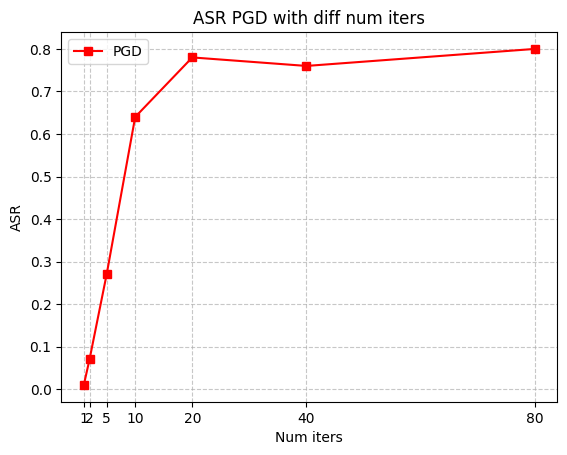

In [10]:
# TODO: рассчитайте ASR для разного числа итераций PGD при фиксированном epsilon=0.15
# TODO: постройте график
epsilon = 0.15
iters = [1,2,5,10,20,40,80]
asr_pgd_iters=[]
indices = list(range(100))
subset_dataset = Subset(test_loader.dataset, indices)
fast_loader = DataLoader(subset_dataset, batch_size=100, shuffle=False)
for iterr in iters:
    asr = evaluate_asr(
        model, fast_loader, pgd_attack, criterion,
        n_batches=10, epsilon=epsilon, alpha=0.02, num_iter=iterr, randomize=True
    )
    asr_pgd_iters.append(asr)
plt.plot(iters, asr_pgd_iters, marker='s', linestyle='-', color='red', label='PGD')

plt.title('ASR PGD with diff num iters')
plt.xlabel('Num iters')
plt.ylabel('ASR')
plt.xticks(iters)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

**Вопрос для отчёта:** при каком числе итераций ASR практически перестаёт расти? Как это соотносится с утверждением лекции о том, что одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки?

_Ваш ответ:_  
При 20 иттерациях PGD выравнилось значение ASR  
FGSM это по сути PGD с одной иттерацией. Поэтому FGSM с фиксированным epsilon дает нам лишь нижнюю оценку силы атаки. При увеличении количества иттераций возрастает и "урон" - модель начинает чаще ошибаться.

### 2.5. Adversarial training через PGD (седловая точка)

**Задание:** обучите вторую модель с adversarial training по формулировке седловой точки Мадри:

$$
\min_{\theta} \mathbb{E}_{(x,y)} \left[ \max_{\delta \in \mathcal{S}} L(\theta, x+\delta, y) \right]
$$

На каждом шаге обучения внутренний максимум приближайте PGD с небольшим числом итераций (5-7), а внешний шаг оптимизации делайте по параметрам модели на полученных adversarial-примерах.

In [11]:
# TODO: реализуйте цикл adversarial training
# На каждом батче:
# 1. Постройте x_adv через pgd_attack (5-7 итераций, epsilon=0.15)
# 2. Посчитайте loss на x_adv
# 3. Сделайте шаг оптимизации
adv_model = SmallCNN().to(device)
opt_adv = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

num_epochs = 3
adv_model.train()
for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        x_adv = pgd_attack(
            model=adv_model,
            x=images,
            y=labels,
            epsilon=0.15,
            alpha=0.02,
            num_iter=7,
            criterion=criterion,
            randomize=True
        )

        opt_adv.zero_grad()

        outputs_adv = adv_model(x_adv)
        loss_adv = criterion(outputs_adv, labels)
        loss_adv.backward()
        opt_adv.step()

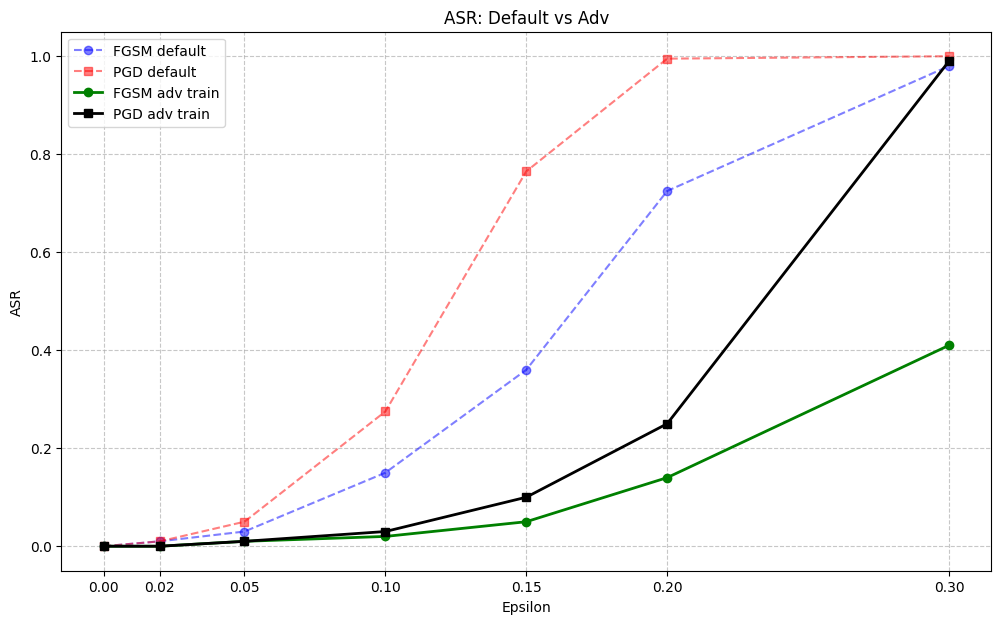

In [12]:
# TODO: постройте график ASR(epsilon) для adv_model против FGSM и против PGD
# Сравните на одном графике с результатами обычной модели из п.2.3
asr_fgsm_adv = []
asr_pgd_adv = []

indices = list(range(100))
subset_dataset = Subset(test_loader.dataset, indices)
fast_loader = DataLoader(subset_dataset, batch_size=100, shuffle=False)

for eps in epsilons:
    asr_f_adv = evaluate_asr(
        adv_model, fast_loader, fgsm_attack, criterion,
        n_batches=1, epsilon=eps
    )
    asr_fgsm_adv.append(asr_f_adv)

    asr_p_adv = evaluate_asr(
        adv_model, fast_loader, pgd_attack, criterion,
        n_batches=1, epsilon=eps, alpha=0.02, num_iter=20, randomize=True
    )
    asr_pgd_adv.append(asr_p_adv)

plt.figure(figsize=(12, 7))
plt.plot(epsilons, asr_fgsm, marker='o', linestyle='--', color='blue', alpha=0.5, label='FGSM default')
plt.plot(epsilons, asr_pgd, marker='s', linestyle='--', color='red', alpha=0.5, label='PGD default')

plt.plot(epsilons, asr_fgsm_adv, marker='o', linestyle='-', color='green', linewidth=2, label='FGSM adv train')
plt.plot(epsilons, asr_pgd_adv, marker='s', linestyle='-', color='black', linewidth=2, label='PGD adv train')

plt.title('ASR: Default vs Adv')
plt.xlabel('Epsilon')
plt.ylabel('ASR')
plt.xticks(epsilons)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

**Вопрос для отчёта:** насколько снизился ASR против PGD и против FGSM после adversarial training? Согласуется ли результат с идеей «универсального первопорядкового противника» — устойчивость к PGD переносится на устойчивость к более слабым атакам?

_Ваш ответ:_  
Результат согласуется с теорией о том, что устойчивость к PGD переносится на более слабые атаки (FGSM). После повышения устойчивости модели ASR для PGD атаки упал примерно в 4 раза, для FGSM атаки примерно в 5 раз (при epsilon = 0.2)

## Часть III. Атака Carlini & Wagner (C&W)

### 3.1. Реализация целевой C&W L2-атаки

**Задание:** реализуйте C&W-атаку (вариант L2, целевая) по следующей схеме:

1. Замена переменных: $ x' = \frac{1}{2}(tanh(w)+1) $ — гарантирует $x' \in [0,1]$ без явного clipping.
2. Функция потерь на логитах с параметром confidence κ:
$ f(x') = \max\left( \max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa \right) $
3. Итоговая целевая функция:

$ \min_{w} \left\| \tfrac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\left(\tfrac{1}{2}(\tanh(w)+1)\right) $

4. Оптимизация через Adam по переменной $w$.

In [13]:
# TODO: реализуйте функцию C&W L2-атаки
def cw_l2_attack(model, x, target_class, c=1.0, kappa=0.0, num_steps=200, lr=0.01):
    # TODO:
    # 1. Инициализируйте w = atanh(2x - 1) (с ограничением диапазона для избежания inf)
    # 2. Создайте optimizer Adam по w
    # 3. Цикл num_steps раз:
    #    - x_adv = 0.5 * (tanh(w) + 1)
    #    - получите логиты через model(x_adv)
    #    - вычислите f(x_adv) по формуле выше (max_other_logit - target_logit, ограниченный -kappa)
    #    - вычислите dist_loss = ||x_adv - x||^2
    #    - loss = dist_loss + c * f_loss
    #    - backward и шаг оптимизатора
    # 4. Верните финальный x_adv
    model.eval()
    batch_size = x.size(0)
    device = x.device

    x_clipped = torch.clamp(x, 1e-6, 1 - 1e-6)
    w = torch.atanh(2 * x_clipped - 1).detach()
    w.requires_grad = True

    optimizer = torch.optim.Adam([w], lr=lr)

    for _ in range(num_steps):
        x_adv = 0.5 * (torch.tanh(w) + 1)

        logits = model(x_adv)


        target_logits = logits[torch.arange(batch_size), target_class]
        logits_masked = logits.clone()
        logits_masked[torch.arange(batch_size), target_class] = -1e9
        max_other_logits, _ = torch.max(logits_masked, dim=1)

        # f_loss = max(max_other_logit - target_logit, -kappa)
        f_loss = torch.clamp(max_other_logits - target_logits, min=-kappa)

        dist_loss = torch.sum((x_adv - x) ** 2, dim=(1, 2, 3))

        loss = dist_loss + c * f_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return x_adv.detach()


### 3.2. Демонстрация целевой атаки

**Задание:** выберите тестовый пример и целевой класс (отличный от истинного), постройте adversarial-пример методом C&W (κ=0) и визуализируйте: оригинал, возмущение (с указанием L2-нормы), adversarial-пример (с предсказанием и confidence).

L2-норма возмущения: 2.5685


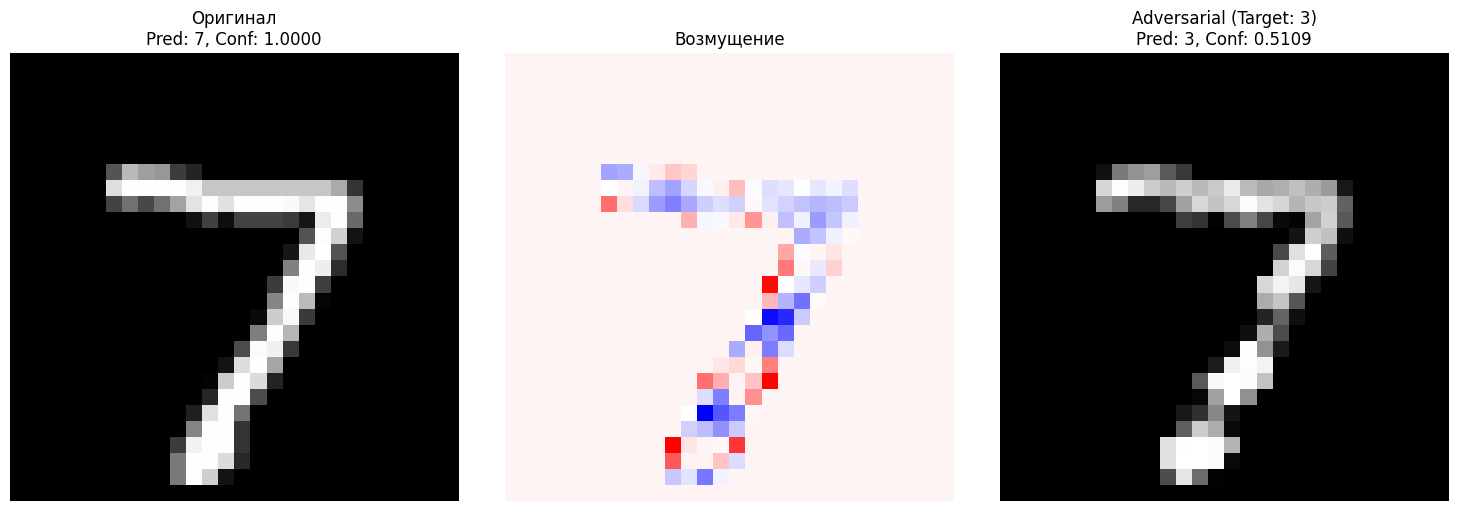

In [58]:
# TODO: выберите пример, задайте target_label
# TODO: примените cw_l2_attack
# TODO: визуализируйте результат, рассчитайте L2-норму возмущения
images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)
true_label = labels[0].item()
target_label = 3
target_tensor = torch.tensor([target_label]).to(device)

x_adv = cw_l2_attack(
    model, image, target_tensor,
    c=3.0, kappa=0.0, num_steps=200, lr=0.01
)
img_np  = image[0, 0].detach().cpu().numpy()
adv_np  = x_adv[0, 0].detach().cpu().numpy()
pert_np = adv_np - img_np
l2_norm = torch.norm(x_adv - image, p=2).item()
print(f"L2-норма возмущения: {l2_norm:.4f}")

model.eval()
with torch.no_grad():
    out_orig = model(image)
    prob_orig = torch.softmax(out_orig, dim=1)
    pred_orig = out_orig.argmax(dim=1).item()
    conf_orig = prob_orig[0, pred_orig].item()

    out_adv = model(x_adv)
    prob_adv = torch.softmax(out_adv, dim=1)
    pred_adv = out_adv.argmax(dim=1).item()
    conf_adv = prob_adv[0, pred_adv].item()

    conf_target = prob_adv[0, target_label].item()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f"Оригинал\nPred: {pred_orig}, Conf: {conf_orig:.4f}")
axes[0].axis('off')

axes[1].imshow(pert_np, cmap='bwr')
axes[1].set_title(f"Возмущение")
axes[1].axis('off')

# Состязательный пример
axes[2].imshow(adv_np, cmap='gray')
axes[2].set_title(f"Adversarial (Target: {target_label})\nPred: {pred_adv}, Conf: {conf_adv:.4f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 3.3. Влияние параметра confidence κ

**Задание:** для того же примера постройте C&W-атаки с κ ∈ {0, 5, 10, 20, 40} и постройте два графика: (а) зависимость L2-нормы возмущения от κ, (б) зависимость вероятности целевого класса от κ.

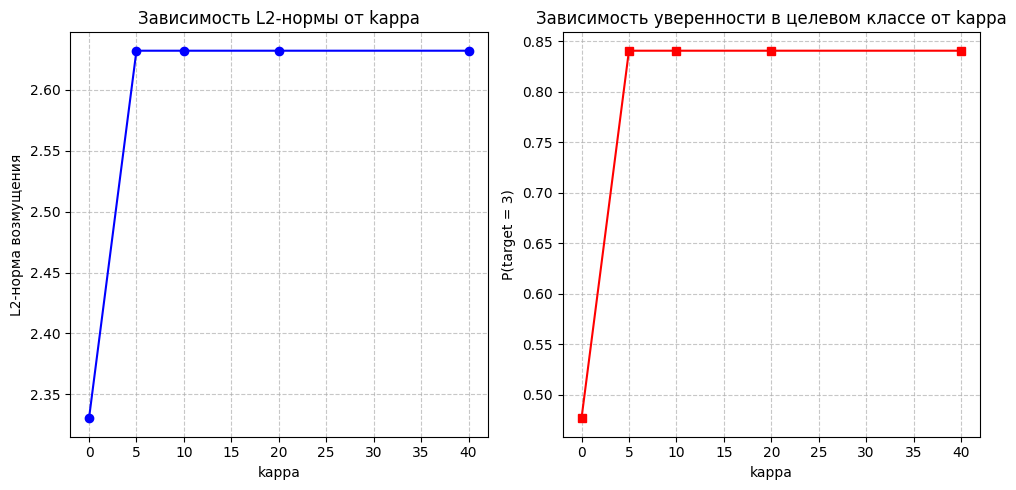

In [74]:
# TODO: постройте атаки для разных значений kappa
# TODO: постройте два графика (L2-норма и confidence целевого класса от kappa)
kappa = [0,5,10,20,40]
l2_history = []
prob_history = []
model.eval()
for k in kappa:
  x_adv = cw_l2_attack(
    model, image, target_tensor,
    c=1.0, kappa=k, num_steps=200, lr=0.01
)
  img_np  = image[0, 0].detach().cpu().numpy()
  adv_np  = x_adv[0, 0].detach().cpu().numpy()
  pert_np = adv_np - img_np
  l2_norm = torch.norm(x_adv - image, p=2).item()
  l2_history.append(l2_norm)

  with torch.no_grad():
        out_adv = model(x_adv)
        prob_adv = torch.softmax(out_adv, dim=1)
        conf_target = prob_adv[0, target_label].item()
  prob_history.append(conf_target)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(kappa, l2_history, marker='o', color='blue')
axes[0].set_xlabel('kappa')
axes[0].set_ylabel('L2-норма возмущения')
axes[0].set_title('Зависимость L2-нормы от kappa')
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(kappa, prob_history, marker='s', color='red')
axes[1].set_xlabel('kappa')
axes[1].set_ylabel(f'P(target = {target_label})')
axes[1].set_title('Зависимость уверенности в целевом классе от kappa')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** как изменяется величина возмущения при росте κ? Объясните этот эффект, опираясь на формулу функции потерь $f(x')$ из лекции.

_Ваш ответ:_  
При выбранных гипермараметрах и архитектуре нейросети при к = 5 значения L2 нормы и уверенности в предсказанном целевом классе выходят на плато. Не удалось увидеть прямую зависимость для L2 нормы и уверенности от к - в теории они должны монотонно возрастать и при достижении определенного уровня к упираться в плато.  
Как только оптимизатор находит возмущение, при котором зазор становится ≥ κ (при kappa=5 это произошло), слагаемое c · f(x') перестаёт давать градиент. Дальше идёт только минимизация расстояния, и решение вышло на плато. Модель просто не может дать большую уверенность в целевом классе для этого конкретного изображения при разумных возмущениях.

## Часть IV. Jacobian-based Saliency Map Attack (JSMA)

### 4.1. Реализация JSMA

**Задание:** реализуйте целевую JSMA-атаку по следующей схеме:

1. Вычислите якобиан выходных вероятностей модели по входу (для всех 10 классов).
2. Постройте saliency-карту: произведение градиента целевого класса и (с обратным знаком) суммарного градиента остальных классов, отбирая только те пиксели, где рост значения пикселя увеличивает вероятность целевого класса и одновременно уменьшает вероятность остальных.
3. На каждой итерации выберите пиксель с максимальной saliency, "насытите" его значение (увеличьте до предела, например, на величину θ=1.0), исключите уже изменённые и предельные пиксели из дальнейшего рассмотрения.
4. Повторяйте, пока не будет достигнута целевая классификация или не будет исчерпан лимит `max_pixels`.

In [76]:
# TODO: реализуйте функцию вычисления якобиана
def compute_jacobian(model, x, num_classes=10):
    # TODO:
    # Для каждого класса c вычислите градиент softmax-вероятности класса c по входу x
    # (используйте torch.autograd.grad с grad_outputs, задающим "единицу" на позиции c)
    # Соберите градиенты в тензор формы (num_classes, *x.shape[1:])
    x_in = x.clone().detach().requires_grad_(True)
    logits = model(x_in)
    probs = torch.softmax(logits, dim=1)

    jacobian = []
    for c in range(num_classes):
        grad_outputs = torch.zeros_like(probs)
        grad_outputs[0, c] = 1.0

        (grad_c,) = torch.autograd.grad(
            outputs=probs,
            inputs=x_in,
            grad_outputs=grad_outputs,
            retain_graph=True,
            create_graph=False,
        )
        jacobian.append(grad_c[0].clone())

    return torch.stack(jacobian, dim=0)

In [77]:
# TODO: реализуйте функцию JSMA-атаки
def jsma_attack(model, x, target_class, max_pixels=60, theta=1.0):
    # TODO:
    # 1. Скопируйте x в x_adv, создайте маску modified (по форме одного изображения, без батча)
    # 2. Цикл до max_pixels раз:
    #    - проверьте текущее предсказание модели, выйдите, если совпадает с target_class
    #    - вычислите якобиан через compute_jacobian
    #    - target_grad = якобиан для целевого класса
    #    - other_grad = сумма якобианов остальных классов
    #    - saliency = target_grad * (other_grad < 0) * |other_grad|
    #    - исключите уже изменённые и насыщенные (>=0.99) пиксели из saliency (установите -inf)
    #    - найдите индекс пикселя с максимальной saliency
    #    - увеличьте значение этого пикселя на theta (не более 1.0), отметьте как изменённый
    # 3. Верните x_adv и число изменённых пикселей
    model.eval()
    device = x.device

    x_adv = x.clone().detach()
    modified_mask = torch.zeros_like(x_adv[0, 0], dtype=torch.bool)
    num_changed = 0

    for _ in range(max_pixels):
        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1).item()
        if pred == target_class:
            break

        jac = compute_jacobian(model, x_adv, num_classes=10)

        target_grad = jac[target_class]
        other_grad  = jac.sum(dim=0) - target_grad

        positive = (target_grad > 0).float()
        negative = (other_grad  < 0).float()
        saliency = target_grad * other_grad.abs() * positive * negative

        if saliency.shape[0] > 1:
            saliency = saliency.sum(dim=0)
        else:
            saliency = saliency.squeeze(0)

        saturated = x_adv[0, 0] >= 0.99
        saliency = saliency.masked_fill(modified_mask, -float('inf'))
        saliency = saliency.masked_fill(saturated, -float('inf'))

        flat_idx = saliency.argmax().item()
        h, w = flat_idx // saliency.shape[1], flat_idx % saliency.shape[1]

        if saliency[h, w] == -float('inf'):
            break

        x_adv[0, 0, h, w] = min(x_adv[0, 0, h, w].item() + theta, 1.0)
        modified_mask[h, w] = True
        num_changed += 1

    return x_adv, num_changed


### 4.2. Демонстрация точечной атаки

**Задание:** для того же примера и целевого класса, что и в п.3.2, постройте JSMA-атаку и визуализируйте: оригинал, карту изменённых пикселей, adversarial-пример (с предсказанием модели и числом изменённых пикселей).

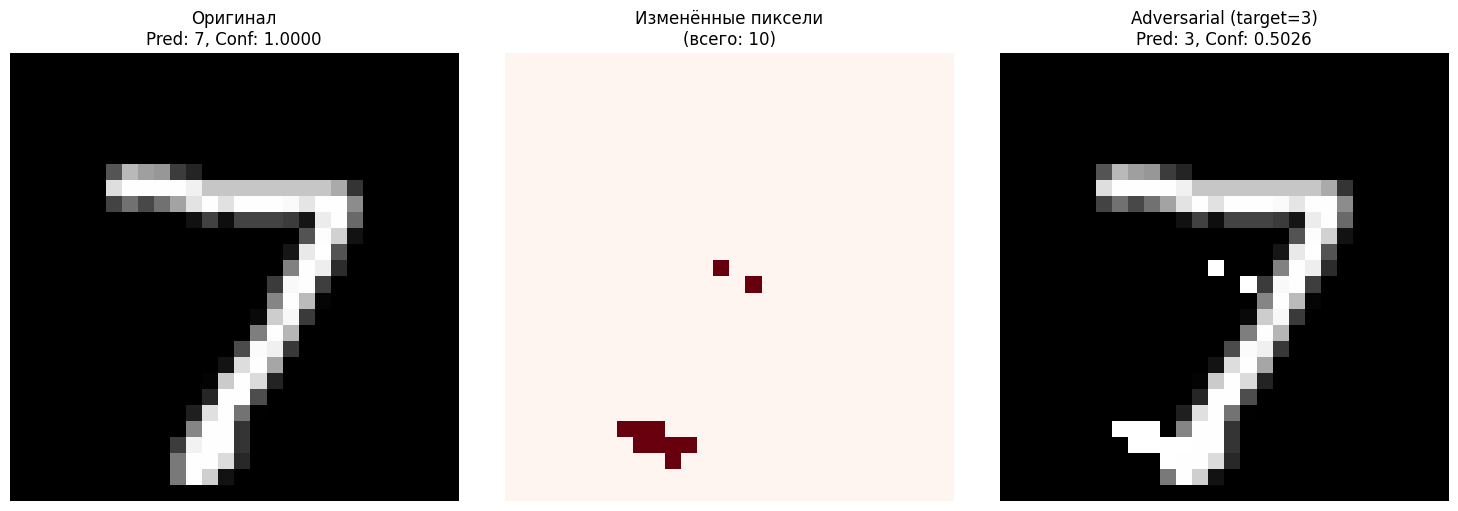

In [78]:
# TODO: примените jsma_attack к тому же примеру и target_label из части III
# TODO: визуализируйте результат (3 подграфика)
x_adv_jsma, num_pixels = jsma_attack(
    model, image, target_label, max_pixels=60, theta=1.0
)

model.eval()
with torch.no_grad():
    out_orig = model(image)
    prob_orig = torch.softmax(out_orig, dim=1)
    pred_orig = out_orig.argmax(dim=1).item()
    conf_orig = prob_orig[0, pred_orig].item()

    out_adv = model(x_adv_jsma)
    prob_adv = torch.softmax(out_adv, dim=1)
    pred_adv = out_adv.argmax(dim=1).item()
    conf_adv = prob_adv[0, pred_adv].item()
    conf_target = prob_adv[0, target_label].item()

diff = (x_adv_jsma - image)[0, 0].detach().cpu().numpy()
changed_mask = (diff != 0).astype(float)

img_np = image[0, 0].detach().cpu().numpy()          # (28, 28)
adv_np = x_adv_jsma[0, 0].detach().cpu().numpy()     # (28, 28)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f"Оригинал\nPred: {pred_orig}, Conf: {conf_orig:.4f}")
axes[0].axis('off')

axes[1].imshow(changed_mask, cmap='Reds', vmin=0, vmax=1)
axes[1].set_title(f"Изменённые пиксели\n(всего: {num_pixels})")
axes[1].axis('off')

axes[2].imshow(adv_np, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"Adversarial (target={target_label})\n"f"Pred: {pred_adv}, Conf: {conf_adv:.4f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** сколько пикселей потребовалось изменить для успешной атаки? Насколько это число мало по сравнению с общим числом пикселей изображения (28×28=784)?

_Ваш ответ:_  
Для успешной атаки потребовалось всего лишь 10 пикселей. По сравнению с общим количеством пикселей это ничтожно мало (1.4%)

## Часть V. Итоговое сравнение атак

**Задание:** для одного и того же исходного изображения и целевого класса постройте атаки всеми тремя методами (целевой PGD, C&W, JSMA) и сравните их в таблице по следующим критериям:
- успешность (достигнут ли целевой класс);
- L2-норма возмущения;
- L∞-норма возмущения;
- число изменённых пикселей (порог изменения > 1e-3).

Постройте также столбчатую диаграмму, сравнивающую три атаки по каждому из трёх числовых критериев.

In [80]:
# TODO: реализуйте функцию целевой PGD-атаки (минимизация loss к целевому классу вместо максимизации к истинному)
def pgd_targeted(model, x, target, epsilon, alpha, num_iter, criterion):
    model.eval()

    delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    delta = (x + delta).clamp(0, 1) - x
    delta.requires_grad = True

    for _ in range(num_iter):
        outputs = model(x + delta)
        loss = criterion(outputs, target)

        if delta.grad is not None:
            delta.grad.zero_()
        loss.backward()

        with torch.no_grad():
            delta.data = delta.data - alpha * delta.grad.sign()
            delta.data = delta.data.clamp(-epsilon, epsilon)
            delta.data = (x + delta.data).clamp(0, 1) - x

    return (x + delta).detach()

In [90]:
# TODO: постройте атаки всеми тремя методами для одного примера и одного target_label
# TODO: соберите результаты в pandas DataFrame (метод, успех, предсказание, L2, Linf, число пикселей)
# TODO: сохраните таблицу в CSV
target_label = 3
target_tensor = torch.tensor([target_label]).to(device)

x_adv_pgd = pgd_targeted(
    model, image, target_tensor,
    epsilon=0.15, alpha=0.05, num_iter=40, criterion=criterion
)

x_adv_cw = cw_l2_attack(
    model, image, target_tensor,
    c=1.0, kappa=1.0, num_steps=200, lr=0.01
)

x_adv_jsma, num_pixels_jsma = jsma_attack(
    model, image, target_label, max_pixels=60, theta=1.0
)

def collect_metrics(x_orig, x_adv, model, target_label):
    model.eval()
    with torch.no_grad():
        pred = model(x_adv).argmax(dim=1).item()
    diff = (x_adv - x_orig).detach()

    l2 = torch.norm(diff, p=2).item()
    linf = diff.abs().max().item()
    n_pix = (diff.abs() > 0.0).sum().item()

    success = (pred == target_label)
    return {
        "pred": pred,
        "success": success,
        "L2": l2,
        "Linf": linf,
        "n_pixels": n_pix,
    }

results = {
    "PGD (targeted)": collect_metrics(image, x_adv_pgd,  model, target_label),
    "C&W L2": collect_metrics(image, x_adv_cw,   model, target_label),
    "JSMA": collect_metrics(image, x_adv_jsma, model, target_label),
}

df = pd.DataFrame(results).T
df.index.name = "Метод"
df = df[["success", "pred", "L2", "Linf", "n_pixels"]]
df.columns = ["Успех", "Pred", "L2", "Linf", "Изменённых пикселей"]
df

,Успех,Pred,L2,Linf,Изменённых пикселей
Метод,,,,,
PGD (targeted),False,7,3.031978,0.15,499
C&W L2,True,3,2.51394,0.762123,784
JSMA,True,3,2.803129,1.0,10


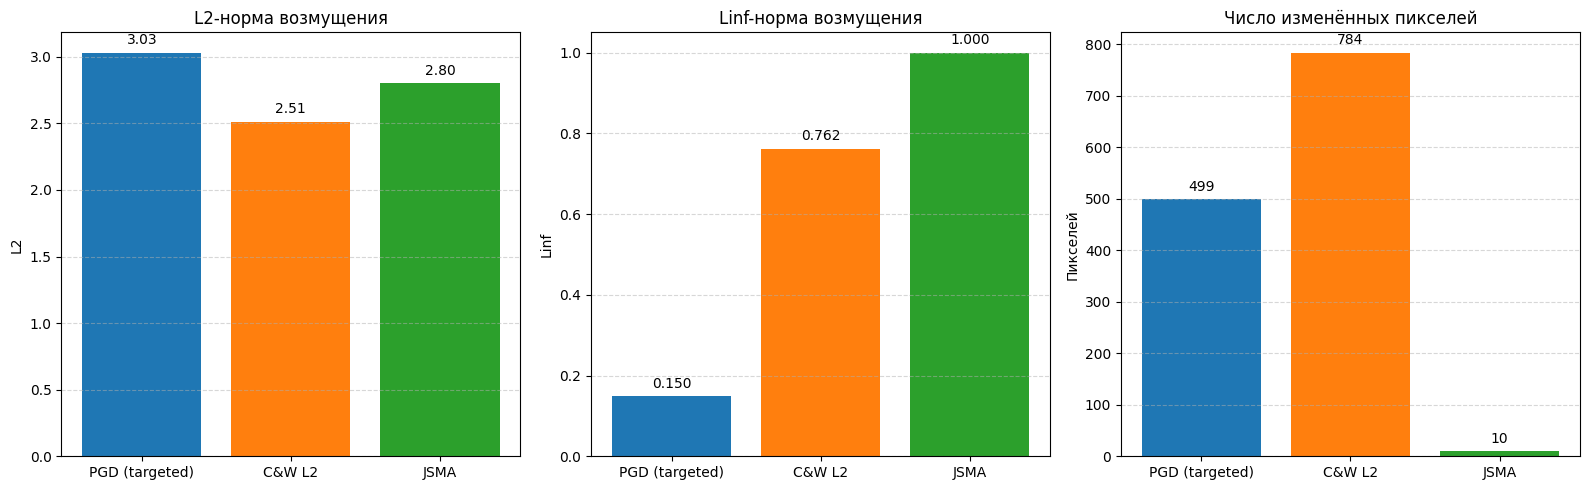

In [91]:
# TODO: постройте столбчатую диаграмму из 3 подграфиков (L2, Linf, число изменённых пикселей)
# для трёх методов
methods = ["PGD (targeted)", "C&W L2", "JSMA"]
colors  = ["tab:blue", "tab:orange", "tab:green"]

l2_vals    = [results[m]["L2"] for m in methods]
linf_vals  = [results[m]["Linf"] for m in methods]
npix_vals  = [results[m]["n_pixels"] for m in methods]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(methods, l2_vals, color=colors)
axes[0].set_title("L2-норма возмущения")
axes[0].set_ylabel("L2")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(l2_vals):
    axes[0].text(i, v + max(l2_vals)*0.02, f"{v:.2f}", ha='center')

axes[1].bar(methods, linf_vals, color=colors)
axes[1].set_title("Linf-норма возмущения")
axes[1].set_ylabel("Linf")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(linf_vals):
    axes[1].text(i, v + max(linf_vals)*0.02, f"{v:.3f}", ha='center')

axes[2].bar(methods, npix_vals, color=colors)
axes[2].set_title("Число изменённых пикселей")
axes[2].set_ylabel("Пикселей")
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(npix_vals):
    axes[2].text(i, v + max(npix_vals)*0.02, f"{v}", ha='center')

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой метод дал наименьшую L2-норму возмущения? Какой — наименьшее число изменённых пикселей? Объясните разницу, опираясь на то, какую норму возмущения оптимизирует каждый метод по своей природе.

_Ваш ответ:_  
Наименьшее количество изменненых пикселей у JSMA атаки. Наименьшая L2 норма у C&W L2 атаки.  
Результаты сходятся с теорией:  
- Наименьшая L2 норма у C&W атаки, так как этот тип атаки оптимизирует L2 норму
- Наименьшее количество пикселей у JSMA это тоже прямое проявление её сути - насыщаем минимальное количество пикселей для успешной атаки
- У C&W атаки измененны все 784 пикселя - корректный результат.
- Наибольшая Linf у JSMA и наименьшая у PGD - тоже согласуется с теорией. PGD фиксирует Linf норму, а JSMA выкручивает отдельные значения в максимум и, как следствие, увеличивает Linf норму

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх изученных методах атак. Почему PGD считается «универсальным первопорядковым противником» и стандартом для adversarial training, тогда как C&W чаще используется как эталон для проверки устойчивости защитных механизмов, а JSMA — как инструмент, ценный своей интерпретируемостью и разреженностью возмущения? В каких прикладных сценариях (например, атаки на изображения высокого разрешения, на табличные данные, на системы обнаружения вторжений) предпочтителен каждый из методов?

_Ваш ответ:_  
Три изученных метода отражают фундаментальный компромисс между нормами возмущения: PGD ограничивает L∞, C&W минимизирует L2, а JSMA стремится к разреженности L0.  
PGD называют «универсальным первопорядковым противником» и стандартом для adversarial training, так как он итеративно использует градиенты для поиска наиболее опасных возмущений в ϵ-шаре.  
C&W служит эталоном для проверки защитных механизмов благодаря оптимизационной природе, позволяющей найти минимально возможное возмущение, достаточное для успеха атаки.  
JSMA, используя разреженность, изменяя лишь несколько ключевых пикселей.  
В прикладных сценариях для изображений высокого разрешения предпочтителен PGD из-за вычислительной эффективности и масштабируемости. Для табличных данных и систем обнаружения вторжений (IDS) чаще выбирают JSMA, так как изменение всех признаков нереалистично, а важна интерпретируемость изменений. C&W применяется как строгий эталон устойчивости в задачах, где критична незаметность атаки.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже с пометкой `# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ`.

### С1. PGD с разными нормами
Реализуйте вариант PGD-атаки с проекцией на $L_2$-шар вместо $L_\infty$ (нормализация градиента по L2-норме на каждом шаге с последующим масштабированием под бюджет ε). Сравните визуально и по ASR с исходным $L_\infty$-вариантом.

### С2. Ускоренная (Maximal) JSMA
Изучите идею ускоренных версий JSMA (например, приближение сложности с $O(M^2 N)$ до $O(M\sqrt{N})$ за счёт эвристического отбора кандидатов вместо полного перебора). Реализуйте упрощённую версию с случайной подвыборкой кандидатов на каждой итерации и сравните скорость и качество атаки с полной версией из Части IV.

### С3. Перенос устойчивости между атаками (adversarial training cross-attack)
Обучите модель с adversarial training на PGD (Часть 2.5). Проверьте её устойчивость не только к PGD и FGSM, но и к C&W и JSMA. Обсудите, перенеслась ли устойчивость на оптимизационные и разреженные атаки, которые не участвовали в обучении.

### С4. Влияние константы c в C&W
Исследуйте, как выбор константы $c$ в целевой функции C&W (без бинарного поиска, вручную для нескольких значений: 0.1, 1, 10, 100) влияет на баланс между успешностью атаки и величиной L2-искажения. Постройте график Success Rate и средней L2-нормы в зависимости от $c$ на нескольких тестовых примерах.


Linf-PGD pred: 3, L2: 3.986
L2-PGD pred: 3, L2: 1.998


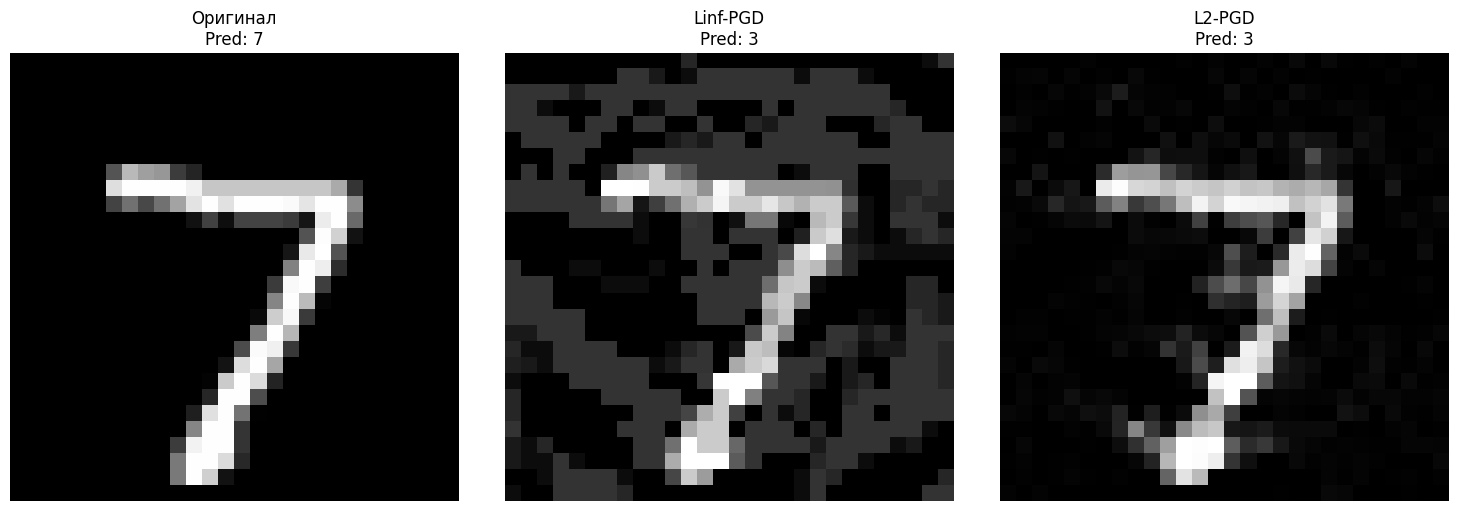

In [120]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ
# TODO: реализуйте выбранные задания (С1-С4) здесь
# Задание С1
def pgd_l2_attack(model, x, target, epsilon, alpha, num_iter, criterion):
    model.eval()
    delta = torch.randn_like(x)
    delta = delta / (delta.view(delta.size(0), -1).norm(p=2, dim=1, keepdim=True).view(-1, 1, 1, 1) + 1e-12)
    delta = delta * epsilon * torch.rand(x.size(0), 1, 1, 1, device=x.device)
    delta = (x + delta).clamp(0, 1) - x
    delta.requires_grad = True

    for _ in range(num_iter):
        outputs = model(x + delta)
        loss = criterion(outputs, target)

        if delta.grad is not None:
            delta.grad.zero_()
        loss.backward()

        with torch.no_grad():
            grad = delta.grad.detach()

            grad_norm = grad.view(grad.size(0), -1).norm(p=2, dim=1, keepdim=True)
            grad_norm = grad_norm.view(-1, 1, 1, 1) + 1e-12
            grad_normalized = grad / grad_norm

            delta.data = delta.data - alpha * grad_normalized

            delta_norm = delta.data.view(delta.size(0), -1).norm(p=2, dim=1, keepdim=True)
            factor = torch.min(torch.ones_like(delta_norm), epsilon / (delta_norm + 1e-12))
            delta.data = delta.data * factor.view(-1, 1, 1, 1)

            delta.data = (x + delta.data).clamp(0, 1) - x

    return (x + delta).detach()

target_tensor = torch.tensor([target_label]).to(device)

x_adv_linf = pgd_targeted(model, image, target_tensor, epsilon=0.2, alpha=0.05, num_iter=40, criterion=criterion)

x_adv_l2 = pgd_l2_attack(model, image, target_tensor, epsilon=2.0, alpha=0.1, num_iter=40, criterion=criterion)

model.eval()
with torch.no_grad():
    pred_linf = model(x_adv_linf).argmax(dim=1).item()
    pred_l2 = model(x_adv_l2).argmax(dim=1).item()

l2_linf = torch.norm(x_adv_linf - image, p=2).item()
linf_linf = (x_adv_linf - image).abs().max().item()

l2_l2 = torch.norm(x_adv_l2 - image, p=2).item()
linf_l2 = (x_adv_l2 - image).abs().max().item()

print(f"Linf-PGD pred: {pred_linf}, L2: {l2_linf:.3f}")
print(f"L2-PGD pred: {pred_l2}, L2: {l2_l2:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
img_np = image[0, 0].detach().cpu().numpy()
axes[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f"Оригинал\nPred: {true_label}")
axes[0].axis('off')

axes[1].imshow(x_adv_linf[0, 0].detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"Linf-PGD\nPred: {pred_linf}")
axes[1].axis('off')

axes[2].imshow(x_adv_l2[0, 0].detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"L2-PGD\nPred: {pred_l2}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

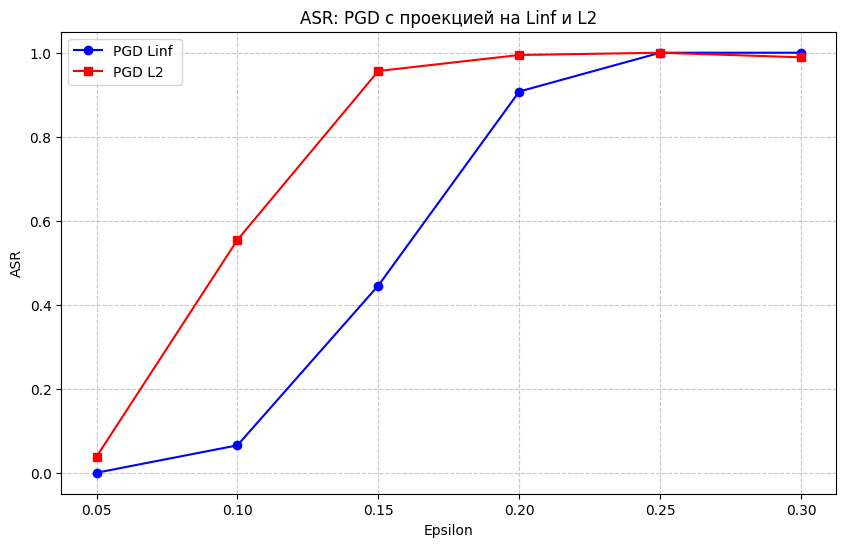

In [124]:
def evaluate_asr_targeted(model, loader, attack_fn, criterion, max_samples=200, target_class=3, **attack_kwargs):
    model.eval()
    device = next(model.parameters()).device
    total, success = 0, 0

    for images, labels in loader:
        if total >= max_samples:
            break

        images = images.to(device)
        labels = labels.to(device)

        targets = torch.full_like(labels, target_class)

        mask = (labels != target_class)
        if mask.sum() == 0:
            continue
        images = images[mask]
        labels = labels[mask]
        targets = targets[mask]

        remaining = max_samples - total
        if images.size(0) > remaining:
            images = images[:remaining]
            labels = labels[:remaining]
            targets = targets[:remaining]

        x_adv = attack_fn(model, images, targets, criterion=criterion, **attack_kwargs)

        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        success += (preds == targets).sum().item()
        total += images.size(0)

    return success / total if total > 0 else 0.0

indices = list(range(200))
subset_dataset = Subset(test_loader.dataset, indices)
fast_loader = DataLoader(subset_dataset, batch_size=100, shuffle=False)
epsilons = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

asr_pgd_linf = []
asr_pgd_l2   = []

for eps in epsilons:
    asr_linf = evaluate_asr_targeted(
        model, fast_loader, pgd_targeted, criterion,
        max_samples=200, epsilon=eps, alpha=0.05, num_iter=20
    )
    asr_pgd_linf.append(asr_linf)

    asr_l2 = evaluate_asr_targeted(
        model, fast_loader, pgd_l2_attack, criterion,
        max_samples=200, epsilon=eps*20, alpha=40*eps, num_iter=40
    )
    asr_pgd_l2.append(asr_l2)


plt.figure(figsize=(10, 6))

plt.plot(epsilons, asr_pgd_linf, marker='o', linestyle='-', color='blue', label=r'PGD Linf ')
plt.plot(epsilons, asr_pgd_l2, marker='s', linestyle='-', color='red', label=r'PGD L2')

plt.title('ASR: PGD с проекцией на Linf и L2')
plt.xlabel('Epsilon')
plt.ylabel('ASR')
plt.xticks(epsilons)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

c =   0.1 | Success Rate = 0.00 | Avg L2 = 0.2544
c =   1.0 | Success Rate = 0.02 | Avg L2 = 1.5358
c =  10.0 | Success Rate = 0.10 | Avg L2 = 2.6114
c = 100.0 | Success Rate = 0.11 | Avg L2 = 2.7578


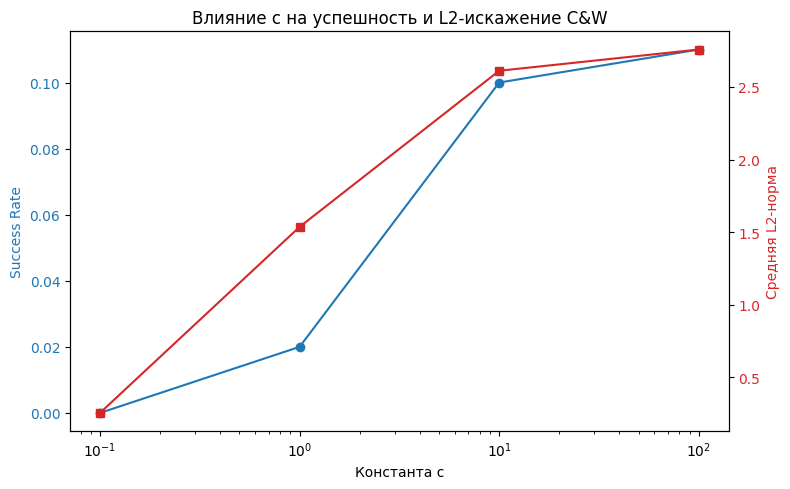

In [119]:
# Задание С4
num_examples = 100
images, labels = next(iter(test_loader))
images = images[:num_examples].to(device)
labels = labels[:num_examples].to(device)

targets = (labels + 1) % 10
c_values = [0.1, 1, 10, 100]

success_rates = []
avg_l2_norms = []

model.eval()
for c in c_values:
    successes = 0
    l2_list = []

    for i in range(num_examples):
        img = images[i].unsqueeze(0) # (1, C, H, W)
        tgt = targets[i].unsqueeze(0) # (1,)

        x_adv = cw_l2_attack(model, img, tgt, c=c, kappa=0.0, num_steps=100, lr=0.01)

        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1).item()
        if pred == tgt.item():
            successes += 1

        l2 = torch.norm(x_adv - img, p=2).item()
        l2_list.append(l2)

    success_rates.append(successes / num_examples)
    avg_l2_norms.append(np.mean(l2_list))
    print(f"c = {c:5.1f} | Success Rate = {success_rates[-1]:.2f} | Avg L2 = {avg_l2_norms[-1]:.4f}")

# Визуализация
fig, ax1 = plt.subplots(figsize=(8, 5))
color1 = 'tab:blue'
ax1.set_xlabel('Константа c')
ax1.set_ylabel('Success Rate', color=color1)
ax1.plot(c_values, success_rates, marker='o', color=color1, label='Success Rate')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Средняя L2-норма', color=color2)
ax2.plot(c_values, avg_l2_norms, marker='s', color=color2, label='Avg L2')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Влияние c на успешность и L2-искажение C&W')
fig.tight_layout()
plt.show()

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: реализация PGD с проекцией, реализация C&W с замерами κ, реализация JSMA на основе якобиана, итоговая сравнительная таблица трёх атак.
